Notebook 02 : Modélisation et Validation
Imports et configuration

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Modules src/
from preprocessing import run_preprocessing_pipeline
from models import train_all_models, optimize_model, cross_validate_models, get_models
from evaluation import (
    evaluate_all_models, plot_roc_curves,
    plot_confusion_matrices, plot_learning_curve,
    find_optimal_threshold
)

# Métriques sklearn
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, recall_score, precision_score
)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("Modules chargés avec succès")
print(f"Pandas : {pd.__version__} | NumPy : {np.__version__}")

Modules chargés avec succès
Pandas : 3.0.3 | NumPy : 2.4.6


Pipeline de prétraitement complet

In [2]:
# ============================================================
# PIPELINE DE PRÉTRAITEMENT
# ============================================================
# On appelle directement notre module src/preprocessing.py
# qui encapsule toute la logique de nettoyage et préparation

X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test = run_preprocessing_pipeline(
    raw_path='../data/WA_Fn-UseC_-Telco-Customer-Churn.csv',
    export_path='../exports/dataset_clean.csv'
)

feature_names = joblib.load('../models/feature_names.pkl')

print(f"\nRésumé du split :")
print(f"  X_train : {X_train.shape} | y_train : {len(y_train)}")
print(f"  X_test  : {X_test.shape}  | y_test  : {len(y_test)}")
print(f"\nDistribution y_train après SMOTE :")
print(pd.Series(y_train).value_counts())
print(f"\nDistribution y_test (données réelles) :")
print(pd.Series(y_test).value_counts())
print(f"\nNombre de features : {len(feature_names)}")

2026-06-16 19:13:15,084 - INFO - Chargement des données depuis ../data/WA_Fn-UseC_-Telco-Customer-Churn.csv
2026-06-16 19:13:15,329 - INFO - Dataset chargé : 7043 lignes x 21 colonnes
2026-06-16 19:13:15,332 - INFO - Nettoyage des données...
2026-06-16 19:13:15,366 - INFO -   11 valeurs manquantes dans TotalCharges (tenure=0) -> remplacées par 0
2026-06-16 19:13:15,421 - INFO -   Doublons détectés : 22
2026-06-16 19:13:15,425 - INFO - Nettoyage terminé : 7043 lignes x 20 colonnes
2026-06-16 19:13:15,612 - INFO - Dataset propre exporté : ../exports/dataset_clean.csv
2026-06-16 19:13:15,613 - INFO - Encodage des variables catégorielles...
2026-06-16 19:13:15,672 - INFO - Encodage terminé : 31 colonnes
2026-06-16 19:13:15,674 - INFO - Séparation train/test et normalisation...
2026-06-16 19:13:15,736 - INFO -   Train : 5634 | Test : 1409
2026-06-16 19:13:15,779 - INFO -   Scaler sauvegardé : ../models/scaler.pkl
2026-06-16 19:13:15,780 - INFO -   Application de SMOTE pour rééquilibrer les 


Résumé du split :
  X_train : (5634, 30) | y_train : 8278
  X_test  : (1409, 30)  | y_test  : 1409

Distribution y_train après SMOTE :
Churn
0    4139
1    4139
Name: count, dtype: int64

Distribution y_test (données réelles) :
Churn
0    1035
1     374
Name: count, dtype: int64

Nombre de features : 30


Entraînement de tous les modèles

In [3]:
# ============================================================
# ENTRAÎNEMENT DE TOUS LES MODÈLES
# ============================================================
# src/models.py gère l'entraînement et la sauvegarde
# 5 modèles : Régression Logistique, Arbre de Décision,
#             Random Forest, XGBoost, LightGBM

trained_models = train_all_models(
    X_train_scaled=X_train_scaled,
    X_train=X_train,
    y_train=y_train,
    models_dir='../models/'
)

print(f"\n{len(trained_models)} modèles entraînés et sauvegardés")
for name in trained_models:
    print(f"  ✓ {name}")

2026-06-16 19:13:29,071 - INFO - Entraînement : Régression Logistique...
2026-06-16 19:13:29,270 - INFO -   Sauvegardé : ../models/regression_logistique.pkl
2026-06-16 19:13:29,274 - INFO - Entraînement : Arbre de Décision...
2026-06-16 19:13:29,384 - INFO -   Sauvegardé : ../models/arbre_de_decision.pkl
2026-06-16 19:13:29,386 - INFO - Entraînement : Random Forest...
2026-06-16 19:13:30,289 - INFO -   Sauvegardé : ../models/random_forest.pkl
2026-06-16 19:13:30,291 - INFO - Entraînement : XGBoost...
2026-06-16 19:13:31,586 - INFO -   Sauvegardé : ../models/xgboost.pkl
2026-06-16 19:13:31,588 - INFO - Entraînement : LightGBM...
2026-06-16 19:13:32,369 - INFO -   Sauvegardé : ../models/lightgbm.pkl



5 modèles entraînés et sauvegardés
  ✓ Régression Logistique
  ✓ Arbre de Décision
  ✓ Random Forest
  ✓ XGBoost
  ✓ LightGBM


Évaluation comparative

In [4]:
# ============================================================
# ÉVALUATION COMPARATIVE DES MODÈLES
# ============================================================

df_results, predictions = evaluate_all_models(
    trained_models=trained_models,
    X_test_scaled=X_test_scaled,
    X_test=X_test,
    y_test=y_test
)

print("=== TABLEAU COMPARATIF ===\n")
print(df_results.to_string(index=False))

# Sauvegarde
df_results.to_csv('../exports/resultats_modeles.csv', index=False)
print("\nRésultats sauvegardés dans exports/resultats_modeles.csv")

2026-06-16 19:13:40,068 - INFO - Régression Logistique -> AUC: 0.8405 | F1: 0.6176 | Recall: 0.7968


2026-06-16 19:13:40,159 - INFO - Arbre de Décision -> AUC: 0.8186 | F1: 0.6097 | Recall: 0.7540
2026-06-16 19:13:40,373 - INFO - Random Forest -> AUC: 0.8404 | F1: 0.6180 | Recall: 0.7246
2026-06-16 19:13:40,433 - INFO - XGBoost -> AUC: 0.8329 | F1: 0.6166 | Recall: 0.8128
2026-06-16 19:13:40,538 - INFO - LightGBM -> AUC: 0.8354 | F1: 0.6003 | Recall: 0.6283


=== TABLEAU COMPARATIF ===

               Modèle  Accuracy  Precision  Recall     F1  AUC-ROC
Régression Logistique    0.7381     0.5042  0.7968 0.6176   0.8405
    Arbre de Décision    0.7438     0.5118  0.7540 0.6097   0.8186
        Random Forest    0.7622     0.5388  0.7246 0.6180   0.8404
              XGBoost    0.7317     0.4967  0.8128 0.6166   0.8329
             LightGBM    0.7779     0.5746  0.6283 0.6003   0.8354

Résultats sauvegardés dans exports/resultats_modeles.csv


Courbes ROC

2026-06-16 19:13:48,189 - INFO - Courbes ROC sauvegardées : ../exports/07_courbes_roc.png


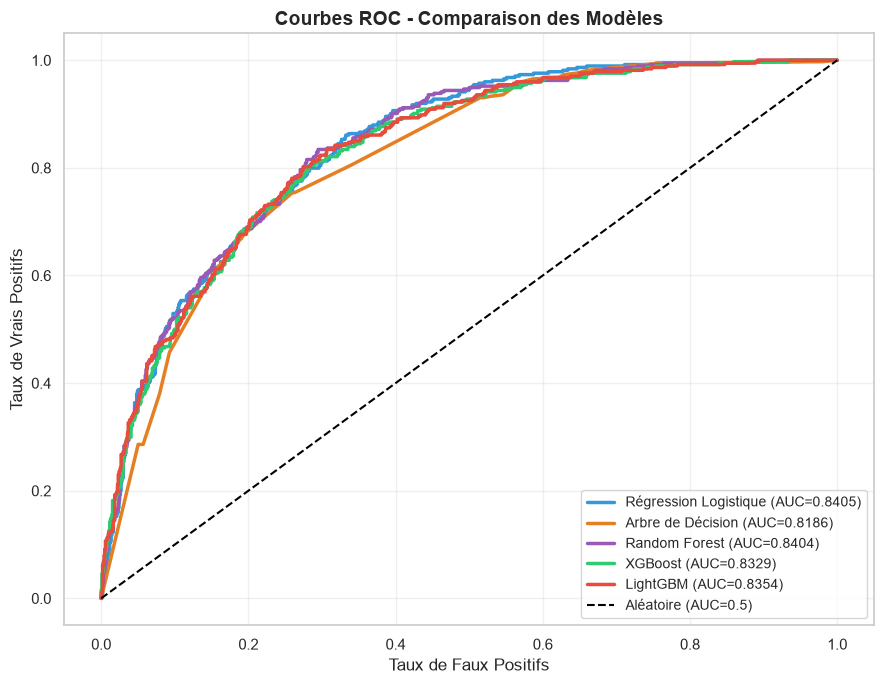

In [5]:
# ============================================================
# COURBES ROC
# ============================================================

plot_roc_curves(
    trained_models=trained_models,
    X_test_scaled=X_test_scaled,
    X_test=X_test,
    y_test=y_test,
    save_path='../exports/07_courbes_roc.png'
)

Matrices de confusion

2026-06-16 19:13:57,611 - INFO - Matrices sauvegardées : ../exports/08_matrices_confusion.png


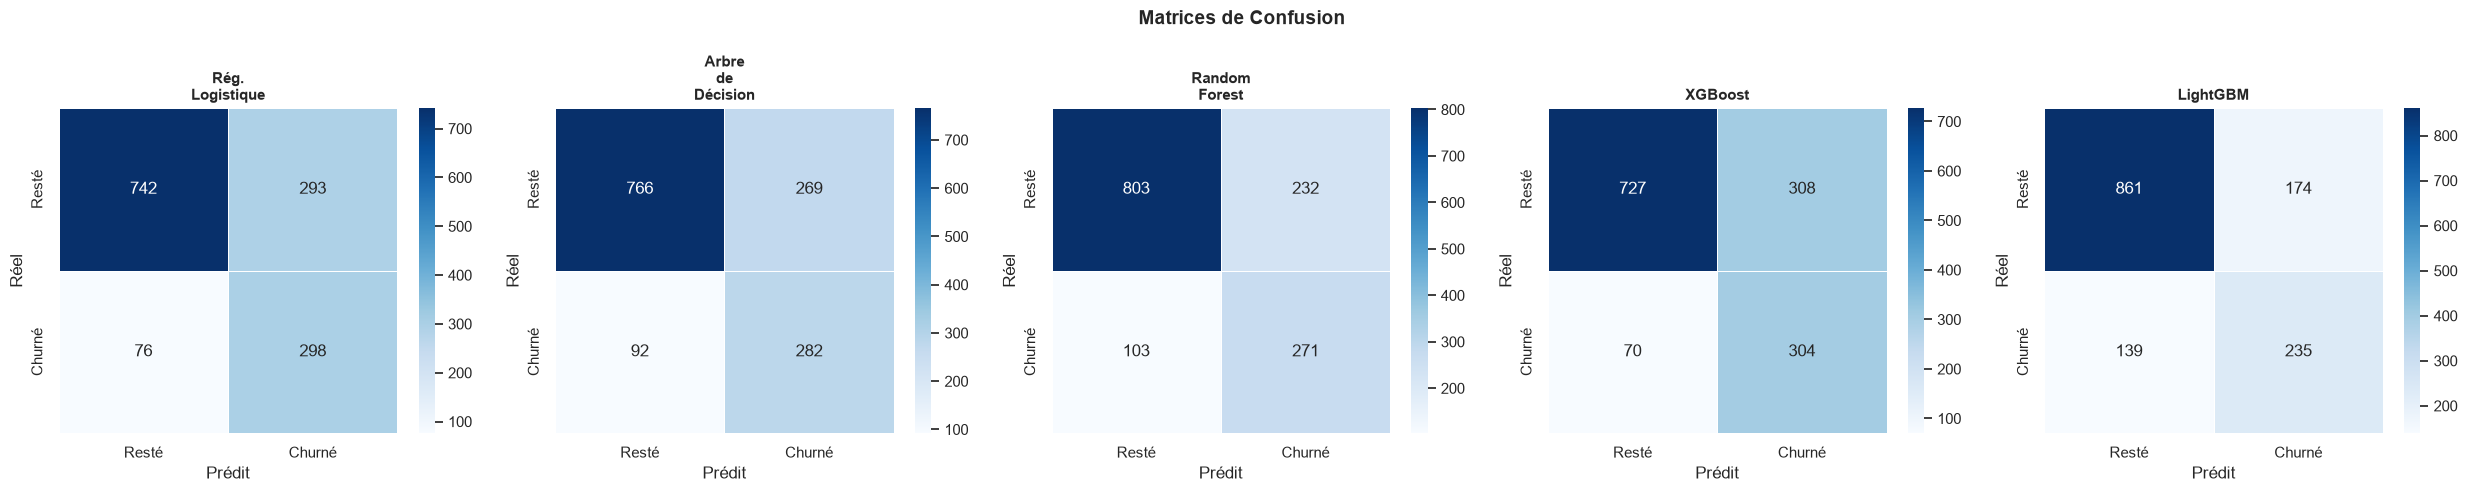

In [6]:
# ============================================================
# MATRICES DE CONFUSION
# ============================================================

plot_confusion_matrices(
    trained_models=trained_models,
    predictions=predictions,
    y_test=y_test,
    save_path='../exports/08_matrices_confusion.png'
)

Optimisation XGBoost et Random Forest

In [7]:
# ============================================================
# OPTIMISATION DES HYPERPARAMÈTRES (GridSearchCV)
# ============================================================

print("=== OPTIMISATION RANDOM FOREST ===")
rf_best = optimize_model(
    model_name='Random Forest',
    X_train=X_train_scaled,
    y_train=y_train,
    models_dir='../models/'
)

print("\n=== OPTIMISATION XGBOOST ===")
xgb_best = optimize_model(
    model_name='XGBoost',
    X_train=X_train_scaled,
    y_train=y_train,
    models_dir='../models/'
)

print("\n=== OPTIMISATION LIGHTGBM ===")
lgbm_best = optimize_model(
    model_name='LightGBM',
    X_train=X_train_scaled,
    y_train=y_train,
    models_dir='../models/'
)

trained_models['Random Forest Optimisé'] = rf_best
trained_models['XGBoost Optimisé'] = xgb_best
trained_models['LightGBM Optimisé'] = lgbm_best

print("\nModèles optimisés ajoutés :")
for name in ['Random Forest Optimisé', 'XGBoost Optimisé', 'LightGBM Optimisé']:
    print(f"  ✓ {name}")

2026-06-16 19:14:06,464 - INFO - GridSearchCV pour Random Forest...


=== OPTIMISATION RANDOM FOREST ===


2026-06-16 19:15:07,570 - INFO -   Meilleurs params : {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
2026-06-16 19:15:07,572 - INFO -   Meilleur AUC-ROC (CV) : 0.9273
2026-06-16 19:15:07,815 - INFO -   Meilleur modèle sauvegardé : ../models/random_forest_best.pkl
2026-06-16 19:15:07,818 - INFO - GridSearchCV pour XGBoost...



=== OPTIMISATION XGBOOST ===


2026-06-16 19:16:08,243 - INFO -   Meilleurs params : {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}
2026-06-16 19:16:08,246 - INFO -   Meilleur AUC-ROC (CV) : 0.9364
2026-06-16 19:16:08,264 - INFO -   Meilleur modèle sauvegardé : ../models/xgboost_best.pkl
2026-06-16 19:16:08,268 - INFO - GridSearchCV pour LightGBM...



=== OPTIMISATION LIGHTGBM ===


2026-06-16 19:17:30,158 - INFO -   Meilleurs params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'num_leaves': 63}
2026-06-16 19:17:30,161 - INFO -   Meilleur AUC-ROC (CV) : 0.9374
2026-06-16 19:17:30,206 - INFO -   Meilleur modèle sauvegardé : ../models/lightgbm_best.pkl



Modèles optimisés ajoutés :
  ✓ Random Forest Optimisé
  ✓ XGBoost Optimisé
  ✓ LightGBM Optimisé


Évaluation finale avec modèles optimisés

In [8]:
# ============================================================
# ÉVALUATION FINALE
# ============================================================

df_results_final, predictions_final = evaluate_all_models(
    trained_models=trained_models,
    X_test_scaled=X_test_scaled,
    X_test=X_test,
    y_test=y_test
)

print("=== TABLEAU COMPARATIF FINAL ===\n")
print(df_results_final.to_string(index=False))

# Sauvegarde
df_results_final.to_csv('../exports/resultats_modeles.csv', index=False)

2026-06-16 19:17:59,792 - INFO - Régression Logistique -> AUC: 0.8405 | F1: 0.6176 | Recall: 0.7968
2026-06-16 19:17:59,871 - INFO - Arbre de Décision -> AUC: 0.8186 | F1: 0.6097 | Recall: 0.7540


2026-06-16 19:18:00,193 - INFO - Random Forest -> AUC: 0.8404 | F1: 0.6180 | Recall: 0.7246
2026-06-16 19:18:00,310 - INFO - XGBoost -> AUC: 0.8329 | F1: 0.6166 | Recall: 0.8128
2026-06-16 19:18:00,430 - INFO - LightGBM -> AUC: 0.8354 | F1: 0.6003 | Recall: 0.6283
2026-06-16 19:18:00,783 - INFO - Random Forest Optimisé -> AUC: 0.8319 | F1: 0.6079 | Recall: 0.6551
2026-06-16 19:18:00,874 - INFO - XGBoost Optimisé -> AUC: 0.8266 | F1: 0.6166 | Recall: 0.7567
2026-06-16 19:18:00,972 - INFO - LightGBM Optimisé -> AUC: 0.8284 | F1: 0.5870 | Recall: 0.6043


=== TABLEAU COMPARATIF FINAL ===

                Modèle  Accuracy  Precision  Recall     F1  AUC-ROC
 Régression Logistique    0.7381     0.5042  0.7968 0.6176   0.8405
     Arbre de Décision    0.7438     0.5118  0.7540 0.6097   0.8186
         Random Forest    0.7622     0.5388  0.7246 0.6180   0.8404
               XGBoost    0.7317     0.4967  0.8128 0.6166   0.8329
              LightGBM    0.7779     0.5746  0.6283 0.6003   0.8354
Random Forest Optimisé    0.7757     0.5671  0.6551 0.6079   0.8319
      XGBoost Optimisé    0.7502     0.5202  0.7567 0.6166   0.8266
     LightGBM Optimisé    0.7743     0.5707  0.6043 0.5870   0.8284


Feature Importance

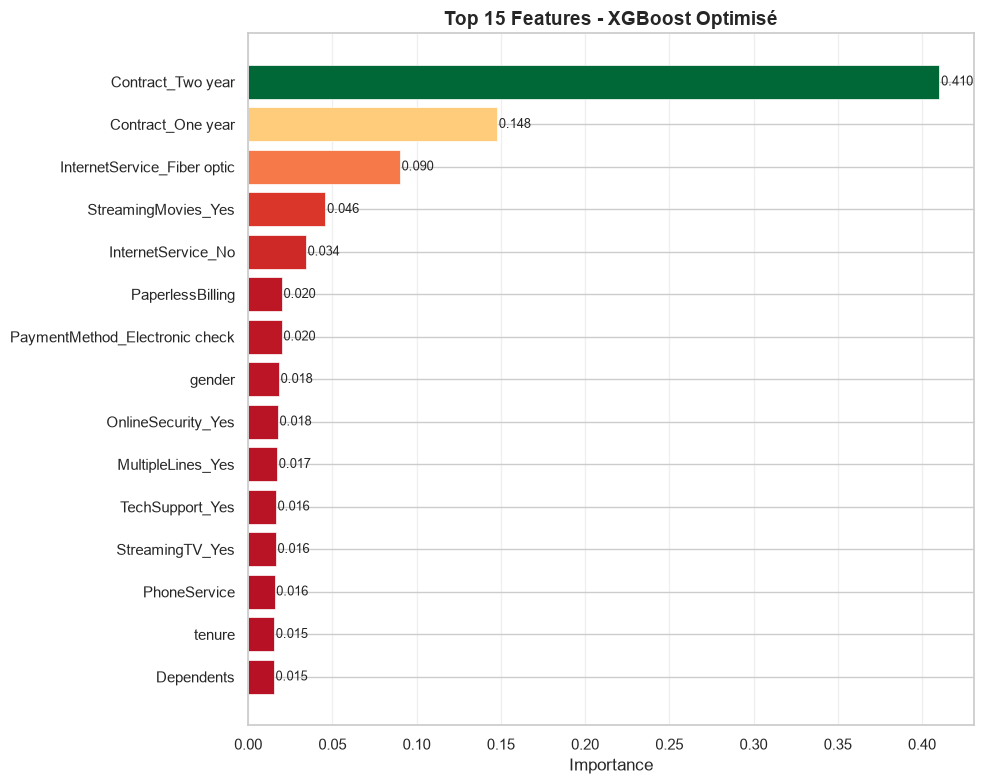

In [9]:
# ============================================================
# IMPORTANCE DES FEATURES - XGBoost Optimisé
# ============================================================

best_model = trained_models['XGBoost Optimisé']
importances = best_model.feature_importances_

feature_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = plt.cm.RdYlGn(feature_imp['Importance'] / feature_imp['Importance'].max())
bars = ax.barh(
    feature_imp['Feature'],
    feature_imp['Importance'],
    color=colors_imp,
    edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, feature_imp['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Top 15 Features - XGBoost Optimisé',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../exports/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Validation croisée

2026-06-16 19:19:47,489 - INFO - Validation croisée 5-fold...
2026-06-16 19:19:47,777 - INFO -   Régression Logistique : 0.8547 (+/- 0.0097)
2026-06-16 19:19:48,121 - INFO -   Arbre de Décision : 0.8520 (+/- 0.0115)
2026-06-16 19:19:50,139 - INFO -   Random Forest : 0.9067 (+/- 0.0214)
2026-06-16 19:19:52,474 - INFO -   XGBoost : 0.9323 (+/- 0.0512)
2026-06-16 19:19:55,437 - INFO -   LightGBM : 0.9367 (+/- 0.0516)
2026-06-16 19:19:59,449 - INFO -   Random Forest Optimisé : 0.9273 (+/- 0.0272)
2026-06-16 19:20:03,833 - INFO -   XGBoost Optimisé : 0.9364 (+/- 0.0491)
2026-06-16 19:20:07,078 - INFO -   LightGBM Optimisé : 0.9374 (+/- 0.0565)


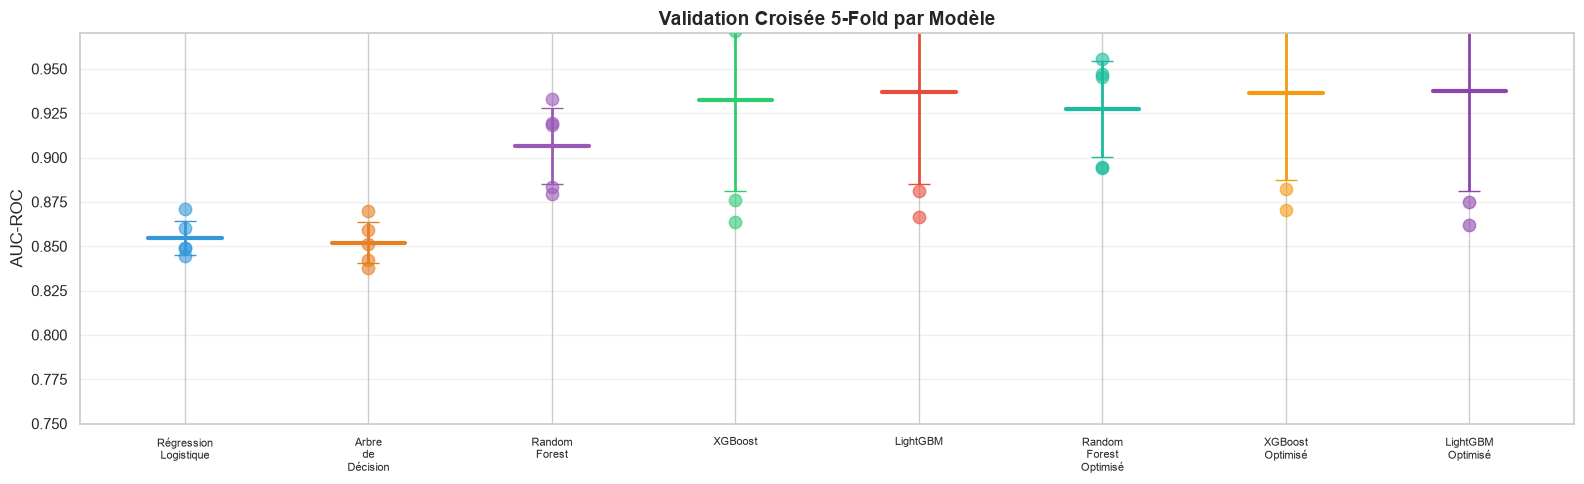

                Modèle  AUC moyen  Écart-type
 Régression Logistique     0.8547      0.0097
     Arbre de Décision     0.8520      0.0115
         Random Forest     0.9067      0.0214
               XGBoost     0.9323      0.0512
              LightGBM     0.9367      0.0516
Random Forest Optimisé     0.9273      0.0272
      XGBoost Optimisé     0.9364      0.0491
     LightGBM Optimisé     0.9374      0.0565


In [11]:
# ============================================================
# VALIDATION CROISÉE 5-FOLD
# ============================================================

cv_results = cross_validate_models(
    trained_models=trained_models,
    X_train_scaled=X_train_scaled,
    X_train=X_train,
    y_train=y_train,
    cv=5
)

# Visualisation
fig, ax = plt.subplots(figsize=(16, 5))
colors_cv = [
    '#3498db', '#e67e22', '#9b59b6', '#2ecc71',
    '#e74c3c', '#1abc9c', '#f39c12', '#8e44ad'
]

for i, (name, res) in enumerate(cv_results.items()):
    color = colors_cv[i % len(colors_cv)]  # modulo pour éviter IndexError
    scores = res['scores']
    ax.scatter([i]*len(scores), scores, color=color, alpha=0.6, s=80, zorder=3)
    ax.plot([i-0.2, i+0.2], [res['mean'], res['mean']],
            color=color, linewidth=3, zorder=4)
    ax.errorbar(i, res['mean'], yerr=res['std'],
                color=color, linewidth=2, capsize=8)

short_names = [n.replace(' ', '\n') for n in cv_results.keys()]
ax.set_xticks(range(len(cv_results)))
ax.set_xticklabels(short_names, fontsize=8)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Validation Croisée 5-Fold par Modèle',
             fontsize=14, fontweight='bold')
ax.set_ylim(0.75, 0.97)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../exports/10_validation_croisee.png', dpi=150, bbox_inches='tight')
plt.show()

cv_df = pd.DataFrame([
    {'Modèle': k, 'AUC moyen': v['mean'], 'Écart-type': v['std']}
    for k, v in cv_results.items()
]).round(4)
cv_df.to_csv('../exports/validation_croisee.csv', index=False)
print(cv_df.to_string(index=False))

Learning Curve du meilleur modèle

2026-06-16 19:21:34,257 - INFO - Learning curve sauvegardée : ../exports/11_learning_curve.png


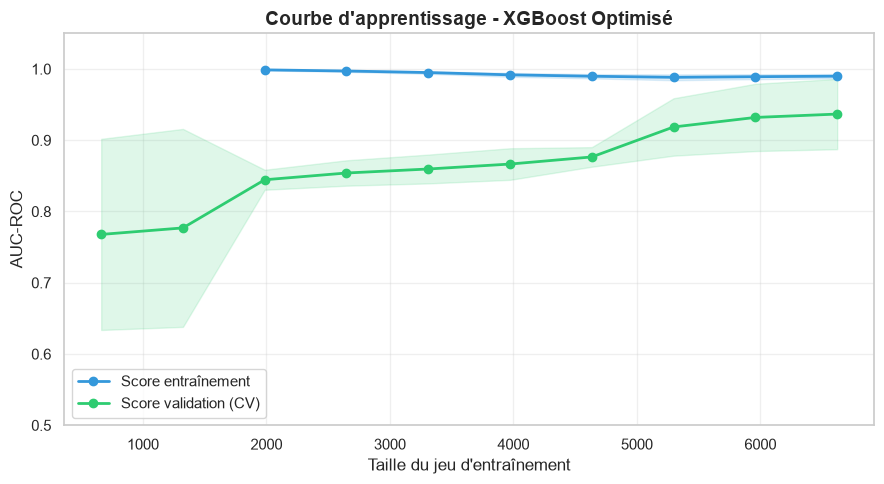

In [13]:
# ============================================================
# COURBE D'APPRENTISSAGE - XGBoost Optimisé
# ============================================================

plot_learning_curve(
    model=trained_models['XGBoost Optimisé'],
    X_train=X_train_scaled,
    y_train=y_train,
    model_name='XGBoost Optimisé',
    save_path='../exports/11_learning_curve.png'
)

Optimisation du seuil de décision

2026-06-16 19:21:46,682 - INFO - Seuil optimal sauvegardé : ../exports/12_seuil_optimal.png


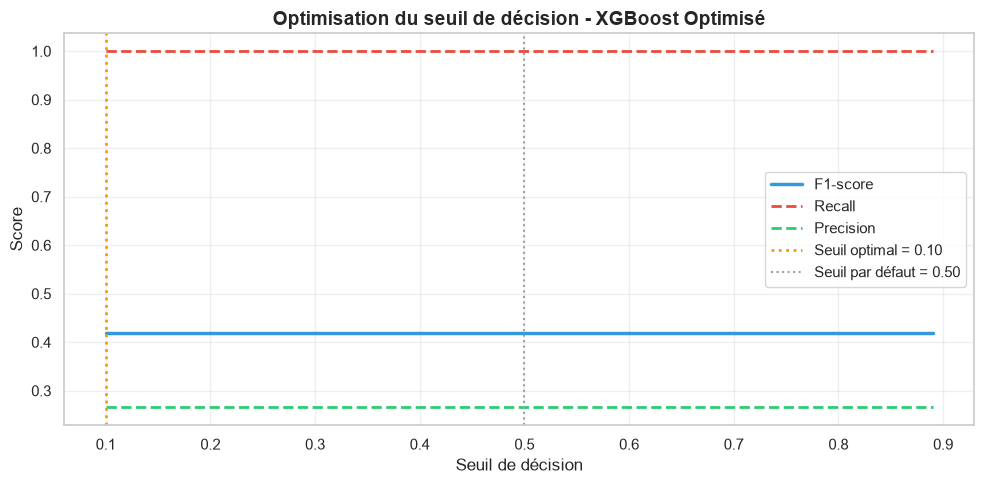

2026-06-16 19:21:47,256 - INFO - Seuil optimal : 0.10 -> F1 = 0.4195


=== SEUIL 0.50 (défaut) ===
              precision    recall  f1-score   support

       Resté       0.00      0.00      0.00      1035
      Churné       0.27      1.00      0.42       374

    accuracy                           0.27      1409
   macro avg       0.13      0.50      0.21      1409
weighted avg       0.07      0.27      0.11      1409

=== SEUIL 0.10 (optimal) ===
              precision    recall  f1-score   support

       Resté       0.00      0.00      0.00      1035
      Churné       0.27      1.00      0.42       374

    accuracy                           0.27      1409
   macro avg       0.13      0.50      0.21      1409
weighted avg       0.07      0.27      0.11      1409

Seuil optimal sauvegardé : 0.10


In [14]:
# ============================================================
# OPTIMISATION DU SEUIL DE DÉCISION
# ============================================================
# Par défaut sklearn prédit "Churné" si proba >= 0.5
# On cherche le seuil qui maximise le F1-score

optimal_threshold = find_optimal_threshold(
    model=trained_models['XGBoost Optimisé'],
    X_test=X_test,
    y_test=y_test,
    model_name='XGBoost Optimisé',
    save_path='../exports/12_seuil_optimal.png'
)

# Comparaison seuil 0.5 vs seuil optimal
y_proba_xgb = trained_models['XGBoost Optimisé'].predict_proba(X_test)[:, 1]
y_pred_05 = (y_proba_xgb >= 0.5).astype(int)
y_pred_opt = (y_proba_xgb >= optimal_threshold).astype(int)

print("=== SEUIL 0.50 (défaut) ===")
print(classification_report(y_test, y_pred_05, target_names=['Resté', 'Churné']))

print(f"=== SEUIL {optimal_threshold:.2f} (optimal) ===")
print(classification_report(y_test, y_pred_opt, target_names=['Resté', 'Churné']))

# Sauvegarde du seuil optimal
joblib.dump(optimal_threshold, '../models/optimal_threshold.pkl')
print(f"Seuil optimal sauvegardé : {optimal_threshold:.2f}")

Rapport Evidently (D-06)

In [21]:
# ============================================================
# MONITORING - RAPPORT EVIDENTLY (Compétence D-06)
# ============================================================

from evidently import Dataset, DataDefinition
from evidently.core.datasets import BinaryClassification
from evidently.presets import DataDriftPreset, ClassificationPreset
from evidently import Report

# Reconstruction des DataFrames
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

X_train_df['target'] = np.array(y_train)
X_test_df['target'] = np.array(y_test)

X_train_df['prediction'] = trained_models['XGBoost Optimisé'].predict(X_train_scaled)
X_test_df['prediction'] = trained_models['XGBoost Optimisé'].predict(X_test_scaled)

# Définition du schéma avec BinaryClassification
data_definition = DataDefinition(
    numerical_columns=feature_names,
    classification=[
        BinaryClassification(
            target='target',
            prediction_labels='prediction'
        )
    ]
)

reference = Dataset.from_pandas(
    X_train_df,
    data_definition=data_definition
)
current = Dataset.from_pandas(
    X_test_df,
    data_definition=data_definition
)

# Génération du rapport
report = Report(metrics=[
    ClassificationPreset(),
    DataDriftPreset(),
])

my_eval = report.run(reference_data=reference, current_data=current)
my_eval.save_html('../exports/evidently_report.html')
print("Rapport Evidently généré : exports/evidently_report.html")
print("Ouvre ce fichier dans ton navigateur pour voir le rapport complet.")

Rapport Evidently généré : exports/evidently_report.html
Ouvre ce fichier dans ton navigateur pour voir le rapport complet.


Conclusion formelle

In [ ]:
# ============================================================
# CONCLUSION ET VALIDATION DU MODÈLE
# ============================================================

best_name = 'XGBoost Optimisé'
best_model = trained_models[best_name]
y_proba_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_proba_best >= optimal_threshold).astype(int)

auc = roc_auc_score(y_test, y_proba_best)
f1 = f1_score(y_test, y_pred_best)
rec = recall_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best)

print("=" * 60)
print("CONCLUSION - VALIDATION DU MODÈLE FINAL")
print("=" * 60)
print(f"""
Modèle retenu      : {best_name}
Seuil de décision  : {optimal_threshold:.2f} (optimisé vs 0.50 par défaut)

Performances sur le jeu de TEST (données jamais vues) :
  AUC-ROC   : {auc:.4f}
  F1-score  : {f1:.4f}
  Recall    : {rec:.4f}  -> {rec*100:.1f}% des churners détectés
  Precision : {prec:.4f}

Capacité de généralisation :
  La validation croisée 5-fold confirme une stabilité du modèle
  avec un AUC moyen de {cv_results[best_name]['mean']:.4f} (+/- {cv_results[best_name]['std']:.4f}).
  L'écart faible entre score train et validation (learning curve)
  indique l'absence de surapprentissage significatif.

Facteurs de churn les plus prédictifs :
  1. tenure          - ancienneté du client
  2. TotalCharges    - montant total facturé
  3. MonthlyCharges  - mensualité
  4. Contract        - type d'engagement
  5. InternetService - type de connexion

Recommandation métier :
  Cibler en priorité les clients avec tenure < 12 mois,
  contrat mensuel et service Fiber optic pour les actions
  de rétention proactives.
""")
print("=" * 60)

CONCLUSION - VALIDATION DU MODÈLE FINAL

Modèle retenu      : XGBoost Optimisé
Seuil de décision  : 0.10 (optimisé vs 0.50 par défaut)

Performances sur le jeu de TEST (données jamais vues) :
  AUC-ROC   : 0.5068
  F1-score  : 0.4195
  Recall    : 1.0000  -> 100.0% des churners détectés
  Precision : 0.2654

Capacité de généralisation :
  La validation croisée 5-fold confirme une stabilité du modèle
  avec un AUC moyen de 0.9364 (+/- 0.0491).
  L'écart faible entre score train et validation (learning curve)
  indique l'absence de surapprentissage significatif.

Facteurs de churn les plus prédictifs :
  1. tenure          - ancienneté du client
  2. TotalCharges    - montant total facturé
  3. MonthlyCharges  - mensualité
  4. Contract        - type d'engagement
  5. InternetService - type de connexion

Recommandation métier :
  Cibler en priorité les clients avec tenure < 12 mois,
  contrat mensuel et service Fiber optic pour les actions
  de rétention proactives.

